# Unemployment Analysis in India
This notebook explores unemployment trends, regional differences, and the impact of Covid-19 using Python.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Unemployment in India.csv")  # replace with your dataset name
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


Here I imported the required libraries (pandas, matplotlib, seaborn) and loaded the dataset.
I used df.info() and df.describe() to check the structure, data types, and summary statistics.


In [4]:
print(df.columns)


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


Here I printed the column names of the dataset to check for any extra spaces or formatting issues.
This step helps confirm the exact names of each column (like 'Region', 'Date', 'Frequency', etc.)
so that I can reference them correctly in later analysis without running into errors such as KeyError.


In [9]:
# Clean column names (remove hidden spaces)
df.columns = df.columns.str.strip()

# Convert Date column safely
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where Date couldn't be parsed
df = df.dropna(subset=['Date'])


/tmp/ipykernel_2790/4117952667.py:5: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In this step, I cleaned the column names to remove any hidden spaces so they can be accessed correctly.
Next, I converted the 'Date' column into proper datetime format using pd.to_datetime.
I used errors='coerce' to handle invalid date values safely, which converts them into NaT (Not a Time).
Finally, I dropped rows where the 'Date' could not be parsed to ensure the dataset is clean and ready for time-based analysis.


In [10]:
print(df['Date'].head(10))


0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
5   2019-10-31
6   2019-11-30
7   2019-12-31
8   2020-01-31
9   2020-02-29
Name: Date, dtype: datetime64[ns]


Here I printed the first 10 values from the 'Date' column to verify that the conversion to datetime format worked correctly.
This step ensures that the dates are now in a proper YYYY-MM-DD format, which is essential for time-based analysis and plotting.
By checking a sample of values, I confirmed that the dataset is clean and ready for further visualizations.


In [11]:
# Clean column names (remove hidden spaces)
df.columns = df.columns.str.strip()

# Convert Date column safely
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where Date couldn't be parsed
df = df.dropna(subset=['Date'])

# Quick check
print(df['Date'].head())


0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


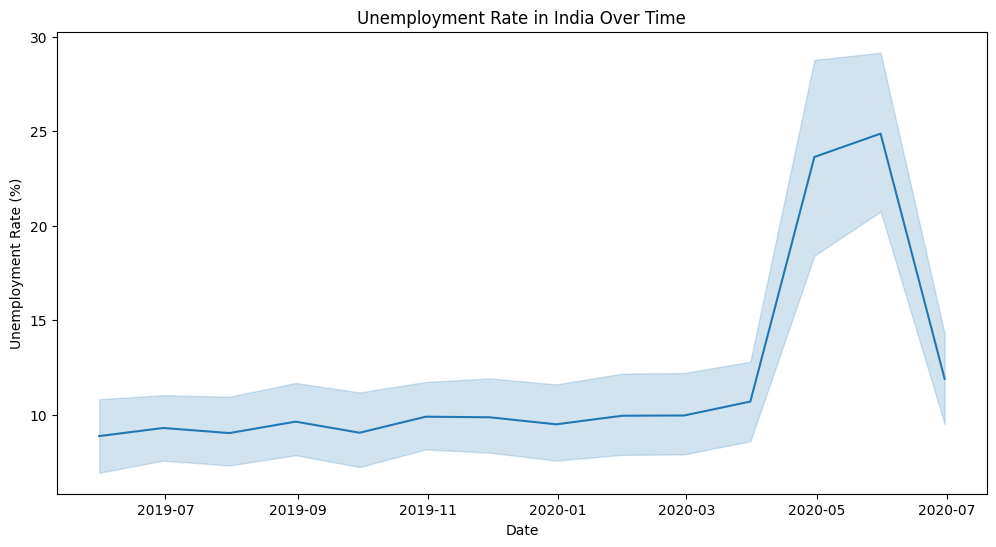

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Unemployment Rate in India Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()


In this step, I created a line plot to visualize how the unemployment rate in India has changed over time.
The x-axis represents the timeline (Date), while the y-axis shows the unemployment rate percentage.
This plot helps identify overall trends, showing periods of stability and highlighting sharp increases, such as during the Covid-19 pandemic.


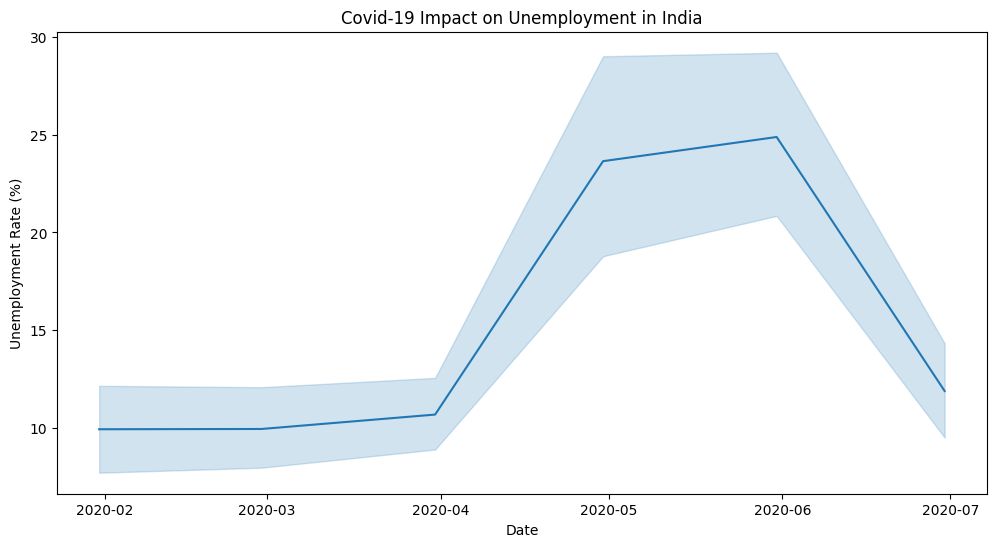

In [13]:
covid_data = df[df['Date'].dt.year >= 2020]
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=covid_data)
plt.title("Covid-19 Impact on Unemployment in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()


In this step, I filtered the dataset to include only records from 2020 onwards.
This allows me to focus on the period affected by the Covid-19 pandemic.
The line plot shows a sharp spike in unemployment during the lockdown months of 2020, followed by a gradual decline as restrictions eased.
This visualization highlights the significant economic disruption caused by Covid-19.


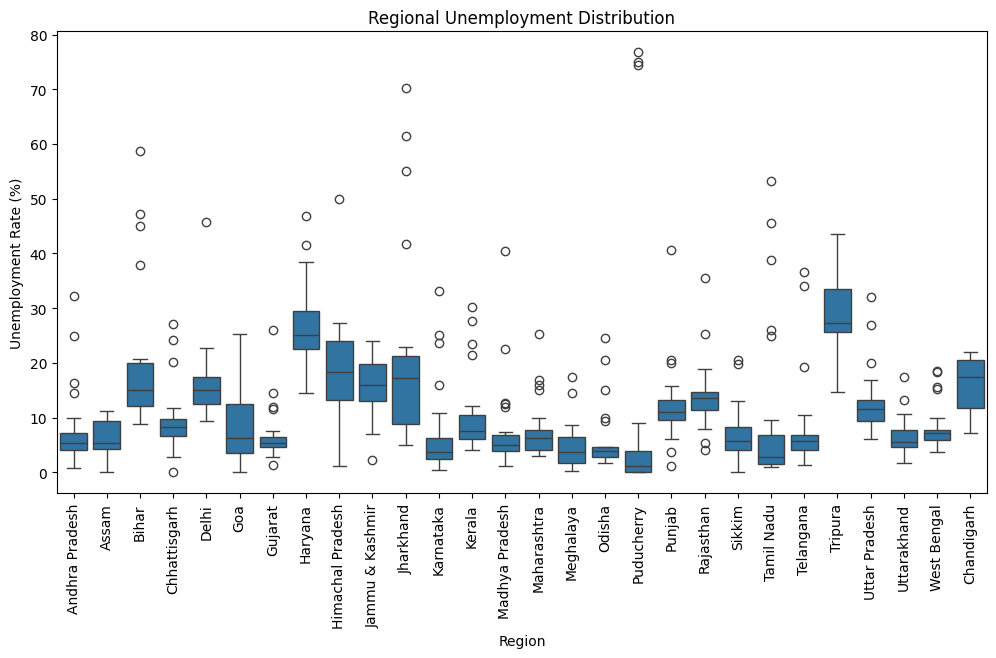

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title("Regional Unemployment Distribution")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.show()


In this step, I created a boxplot to compare unemployment rates across different regions of India.
Each box represents the distribution of unemployment values for a region, showing the median, variability, and outliers.
This visualization highlights regional disparities, where some states consistently show higher unemployment rates than others.
It helps identify which regions may need more targeted policy interventions.


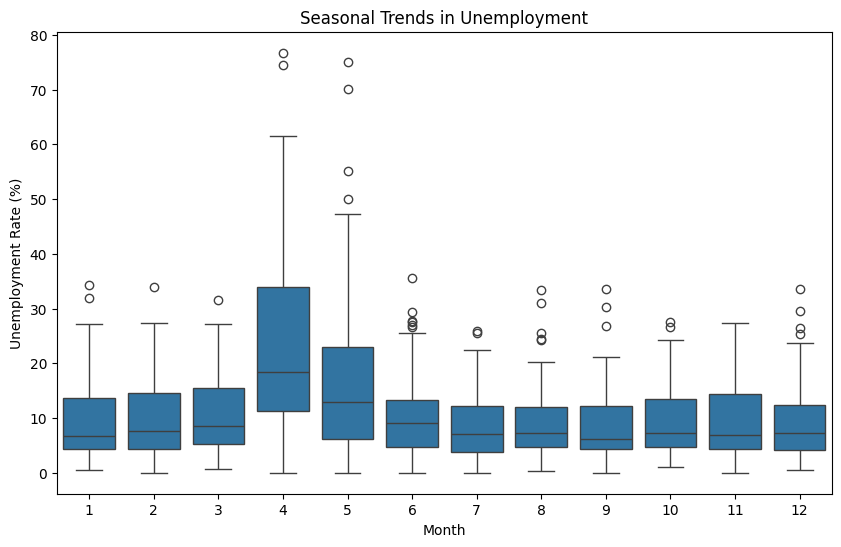

In [15]:
df['Month'] = df['Date'].dt.month
plt.figure(figsize=(10,6))
sns.boxplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Seasonal Trends in Unemployment")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.show()


In this step, I extracted the month from the 'Date' column to analyze seasonal patterns in unemployment.
The boxplot shows how unemployment rates vary across different months of the year.
April (month 4) displays the highest variability, suggesting seasonal cycles in employment, possibly influenced by agriculture or industry activity.
This visualization helps identify months with consistently higher or lower unemployment rates.


## Insights
- Covid-19 had a major impact on unemployment in India.
- Regional disparities highlight areas needing targeted policy support.
- Seasonal cycles suggest employment is influenced by agriculture and industry.
